# DRUG CLASSIFICATION

Задача: предсказать какое лекарство стоит назначить конкретному пациенту

Польза: индивидуальное назначение лекарств пациентам на основе их личных данных

СПРАВКА:
BP - уровни артериального давления  
Cholesterol - уровень холестерина  
Na_to_K - отношение натрия и калия в организме человека.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)

100%|██████████| 1.68k/1.68k [00:00<00:00, 453kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\prathamtripathi\drug-classification\versions\1


In [36]:
df = pd.read_csv("drug200.csv")

In [3]:
df.head(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
df['Drug'].unique()

<ArrowStringArray>
['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str

В датасете имеются различные виды лекарств групп A,B,C,X,Y

---

In [5]:
print("===МИНИМАЛЬНОЕ ОТНОШЕНИЕ===")
print(np.min(df['Na_to_K']))
print("\n===СРЕДНЕЕ ОТНОШЕНИЕ===")
print(np.mean(df['Na_to_K']))
print("\n===МАКСИМАЛЬНОЕ ОТНОШЕНИЕ===")
print(np.max(df['Na_to_K']))

===МИНИМАЛЬНОЕ ОТНОШЕНИЕ===
6.269

===СРЕДНЕЕ ОТНОШЕНИЕ===
16.084485

===МАКСИМАЛЬНОЕ ОТНОШЕНИЕ===
38.247


---


In [8]:
print("===МИНИМАЛЬНЫЙ ВОЗРАСТ===")
print(np.min(df['Age']))
print("\n===СРЕДНИЙ ВОЗРАСТ===")
print(np.median(df['Age']))
print("\n===МАКСИМАЛЬНЫЙ ВОЗРАСТ===")
print(np.max(df['Age']))
print()
print(df['Sex'].value_counts())

===МИНИМАЛЬНЫЙ ВОЗРАСТ===
15

===СРЕДНИЙ ВОЗРАСТ===
45.0

===МАКСИМАЛЬНЫЙ ВОЗРАСТ===
74

Sex
M    104
F     96
Name: count, dtype: int64


Соотношение мужского и женского пола равномерно
Возраст людей в выборке крайне различен с большим уклоном в взрослых и пожилых людей

DrugX и DrugY имеют слишком большой перекос в датафрейме, потому проводить анализ на основе сумм не стоит

---

In [9]:
print(df['BP'].value_counts())
print()
print(df['Cholesterol'].value_counts())
print()
print(df['Drug'].value_counts())

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


---

### По первичному осмотру можно выявить, что в датасете собраны данные о различных пациентах с равномерным количеством людей для каждого признака
Большинство данных являются категориальными, но также имеются количественные данные о возрасте и соотношении натрия к калию в организме человека

---

In [10]:
# Проверка на пропуски

df.isnull().sum().sum()

np.int64(0)

В данном датасете отсутствуют пропуски

---

Text(0.5, 1.0, 'Na_to_K по типам лекарств')

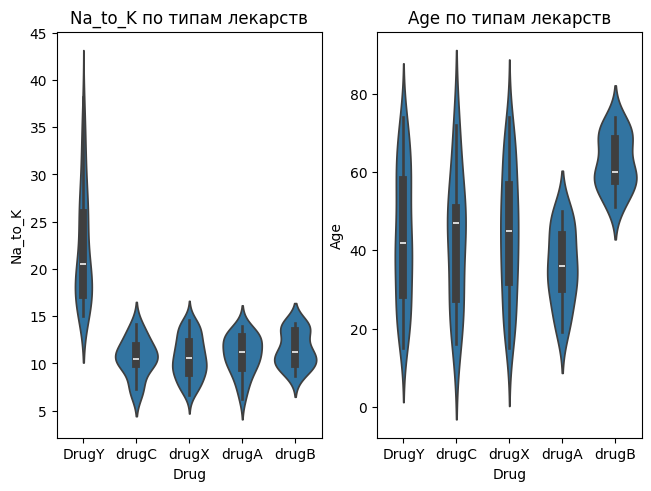

In [11]:
fig, axs = plt.subplots(1, 2, layout='constrained')
# Здесь можно еще боксплот выбрать, но виолин выглядит прикольнее
sns.violinplot(data=df, x="Drug", y="Age", ax=axs[1])
axs[1].set_title("Age по типам лекарств")

sns.violinplot(data=df, x="Drug", y="Na_to_K", ax=axs[0])
axs[0].set_title("Na_to_K по типам лекарств")

### Выше мы рассмотрели количественные признаки
У людей с большим количеством натрия по отношению к калию(na_to_k > 15), наиболее вероятно назначается лекарство DrugY

На соседнем графике можно заметить что для молодых людей наиболее часто назначается drugA, а для пожилых людей назначается drugB

Text(0.5, 1.0, 'Холестирин по типам лекарств')

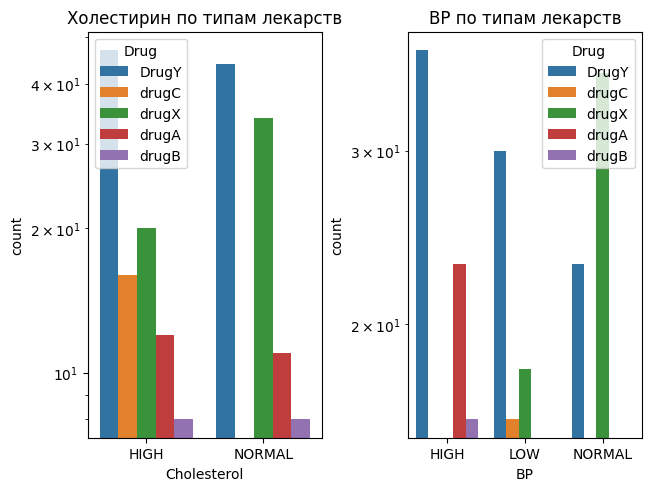

In [12]:
fig, axs = plt.subplots(1, 2, layout='constrained')

sns.countplot(data=df, x="BP", hue="Drug", ax=axs[1])
axs[1].set_yscale('log')
axs[1].set_title("BP по типам лекарств")

sns.countplot(data=df, x="Cholesterol", hue="Drug", ax=axs[0])
axs[0].set_yscale('log')
axs[0].set_title("Холестирин по типам лекарств")

### Генеральные наблюдения на категориальных данных

Лекарства A и B встречаются ТОЛЬКО при высоком уровне артериального давления  
Лекарство C назначается ТОЛЬКО при малом уровне артериального давления

Лекарство C назначается ТОЛЬКо при высоком уровне холестирина

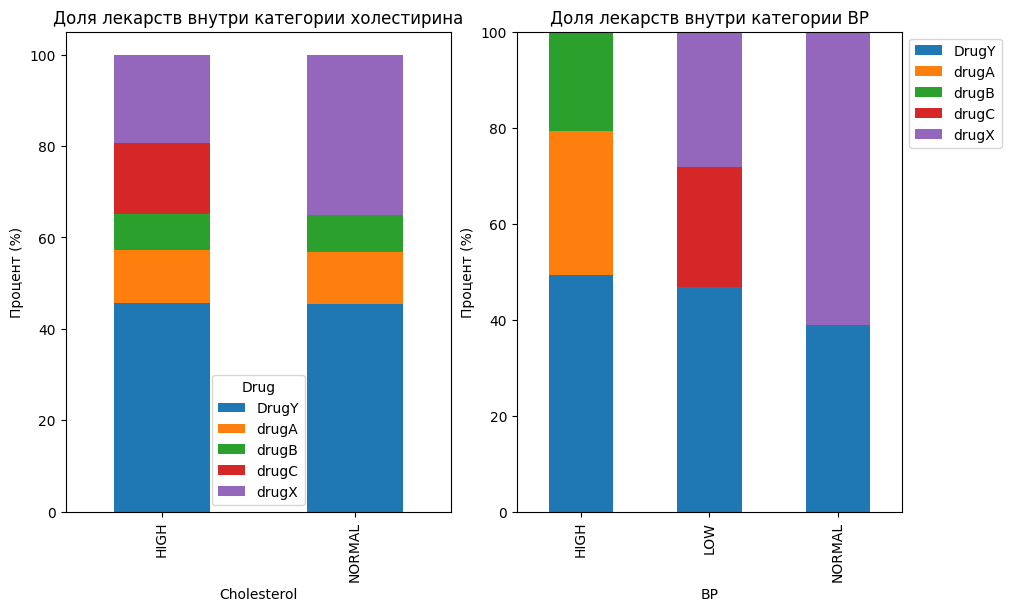

In [13]:
fig, axs = plt.subplots(1, 2, layout='constrained')

ch_dist = pd.crosstab(df['Cholesterol'], df['Drug'], normalize='index') * 100

ch_dist.plot(kind='bar', stacked=True, figsize=(10, 6), ax=axs[0])
axs[0].set_title("Доля лекарств внутри категории холестирина")
axs[0].set_ylabel("Процент (%)")

bp_dist = pd.crosstab(df['BP'], df['Drug'], normalize='index') * 100

bp_dist.plot(kind='bar', stacked=True, figsize=(10, 6), ax=axs[1])
axs[1].set_title("Доля лекарств внутри категории BP")
axs[1].set_ylabel("Процент (%)")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

Тут раннее выявленные правила выражены более отчетливо  
DrugY не зависит от холестирина или артериального давления, ему важен лишь Na_to_K  
При нормальном артериальном давлении и Na_to_K ниже 15, назначается drugX

---

### Выводы после генерального анализа
DrugY имеет сильный перевес в датасете, однако выравнивать значения не имеет смысла, потому что данное лекарство назначается только при Na_to_K выше 15.  
Некоторые лекарства не появляются при различных значениях артериального давления или холестирина.

---


### Кодировка

HIGH, LOW, Normal при LabelEncoding будет кодироваться неправильно  
Будет сделан маппинг значений вручную, чтобы избежать путаницы  
Для Drug будет использован простой LabelEncoding


In [37]:
# Проводим кодировку
le = LabelEncoder()
df['Drug'] = le.fit_transform(df['Drug'])

df['BP'] = df['BP'].map({"LOW": 0, "NORMAL": 1, "HIGH": 2})
df['Cholesterol'] = df['Cholesterol'].map({'NORMAL': 0, 'HIGH': 1})
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

In [15]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,2,1,25.355,0
1,47,0,0,1,13.093,3
2,47,0,0,1,10.114,3
3,28,1,1,1,7.798,4
4,61,1,0,1,18.043,0


---

### Тренировка модели

Данных немного, однако правила явные и для них большая глубина не понадобится  

In [38]:
X = df.drop('Drug', axis=1)
y = df['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [39]:
baseline = df['Drug'].value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline:.2%}")

Baseline Accuracy: 45.50%


In [40]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [41]:
acscore = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accurasy: {acscore:.2%}")

Decision Tree Accurasy: 97.50%


Моя модель справилась 😎😎😎

----

# Ниже решение второго задания


In [42]:
clf1 = DecisionTreeClassifier(random_state=42)
clf1 = clf.fit(X_train, y_train)

clf2 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
clf2 = clf.fit(X_train, y_train)

param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

gd = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
gd = gd.fit(X_train, y_train)

y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)
y_pred3 = gd.predict(X_test)


In [43]:
acscore1 = accuracy_score(y_test, y_pred1)
print(f"Model A: Train: {clf1.score(X_train, y_train)}, Test: {acscore1:.2%}")

acscore2 = accuracy_score(y_test, y_pred2)
print(f"Model B: Train: {clf2.score(X_train, y_train)}, Test: {acscore2:.2%}")

print("GRIDSEARCH=====")
model_v = gd.best_estimator_ 

print(f"Лучшие параметры: {gd.best_params_}")
print(f"Train Acc: {model_v.score(X_train, y_train):.3f}, Test Acc: {model_v.score(X_test, y_test):.3f}")

Model A: Train: 1.0, Test: 97.50%
Model B: Train: 1.0, Test: 97.50%
GRIDSEARCH=====
Лучшие параметры: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Train Acc: 1.000, Test Acc: 0.975


In [44]:
import pandas as pd

# Создаем список словарей с результатами
results = [
    {
        "Алгоритм": "Decision Tree (GridSearch)",
        "Train Acc": model_v.score(X_train, y_train),
        "Test Acc": model_v.score(X_test, y_test),
        "Комментарий": f"Best params: {gd.best_params_}"
    }
]

df_results = pd.DataFrame(results)
display(df_results)

,Алгоритм,Train Acc,Test Acc,Комментарий
0,Decision Tree (GridSearch),1.0,0.975,"Best params: {'criterion': 'gini', 'max_depth'..."


## Naive Bayes

Обучим модель GaussianNB на масштабированных данных.

In [45]:
# Масштабируем данные для Naive Bayes и KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучаем GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Предсказания и точность
y_train_pred_nb = nb_model.predict(X_train_scaled)
y_test_pred_nb = nb_model.predict(X_test_scaled)

train_acc_nb = accuracy_score(y_train, y_train_pred_nb)
test_acc_nb = accuracy_score(y_test, y_test_pred_nb)

print(f"Naive Bayes - Train Accuracy: {train_acc_nb:.4f}")
print(f"Naive Bayes - Test Accuracy: {test_acc_nb:.4f}")

Naive Bayes - Train Accuracy: 0.8375
Naive Bayes - Test Accuracy: 0.9000


### Анализ class_prior_

Проверим, совпадают ли априорные вероятности с пропорциями классов в обучающей выборке.

In [46]:
# Вывод class_prior_
print("class_prior_:", nb_model.class_prior_)
print("Классы:", nb_model.classes_)

# Пропорции классов в обучающей выборке
class_counts = np.bincount(y_train.values)
class_proportions = class_counts / len(y_train)
print("\nПропорции классов в обучающей выборке:", class_proportions)

# Сравнение
print("\nСовпадают ли class_prior_ с пропорциями классов?")
print(np.allclose(nb_model.class_prior_, class_proportions))

class_prior_: [0.45625 0.1125  0.08125 0.08125 0.26875]
Классы: [0 1 2 3 4]

Пропорции классов в обучающей выборке: [0.45625 0.1125  0.08125 0.08125 0.26875]

Совпадают ли class_prior_ с пропорциями классов?
True


### Проверка с равным prior (priors=[0.2, 0.2, 0.2, 0.2, 0.2])

Попробуем задать равные априорные вероятности для всех классов.

In [47]:
# В GaussianNB можно задать priors через параметр priors
# У нас 5 классов, поэтому задаем равные priors
n_classes = len(np.unique(y_train))
equal_priors = [1.0 / n_classes] * n_classes
print(f"Равные priors: {equal_priors}")

# Обучаем модель с равными priors
nb_equal_prior = GaussianNB(priors=equal_priors)
nb_equal_prior.fit(X_train_scaled, y_train)

# Предсказания и точность
y_train_pred_nb_eq = nb_equal_prior.predict(X_train_scaled)
y_test_pred_nb_eq = nb_equal_prior.predict(X_test_scaled)

train_acc_nb_eq = accuracy_score(y_train, y_train_pred_nb_eq)
test_acc_nb_eq = accuracy_score(y_test, y_test_pred_nb_eq)

print(f"\nNaive Bayes (равные priors) - Train Accuracy: {train_acc_nb_eq:.4f}")
print(f"Naive Bayes (равные priors) - Test Accuracy: {test_acc_nb_eq:.4f}")

print(f"\nИзменение точности на тесте: {test_acc_nb:.4f} -> {test_acc_nb_eq:.4f} ({test_acc_nb_eq - test_acc_nb:+.4f})")

Равные priors: [0.2, 0.2, 0.2, 0.2, 0.2]

Naive Bayes (равные priors) - Train Accuracy: 0.8313
Naive Bayes (равные priors) - Test Accuracy: 0.9000

Изменение точности на тесте: 0.9000 -> 0.9000 (+0.0000)


### Почему изменился результат?

При использовании равных priors модель игнорирует реальное распределение классов в обучающей выборке. 
Если классы несбалансированы, это может ухудшить качество модели, так как она начинает считать все классы равновероятными, 
хотя в реальности некоторые классы встречаются чаще других.

### Гистограмма уверенности модели

Построим распределение максимальных вероятностей предсказаний для тестовой выборки.

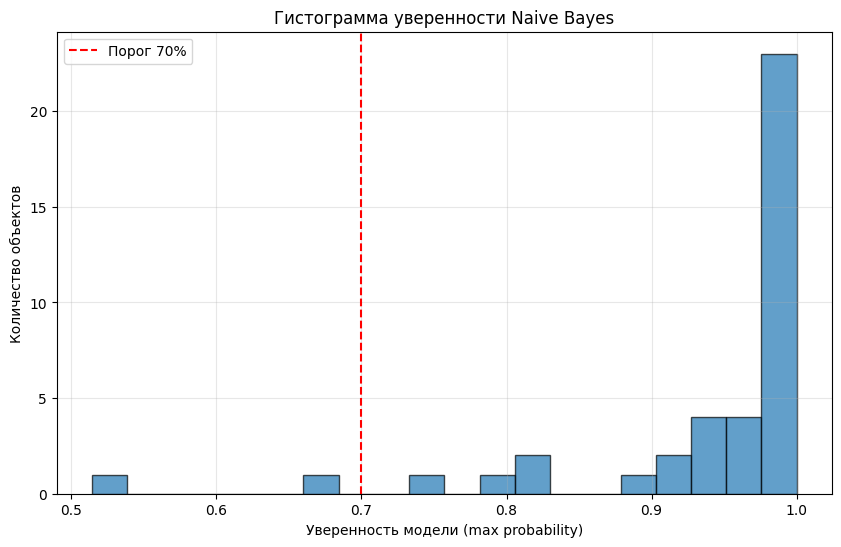

Объектов в зоне неопределенности (уверенность < 70%): 2 из 40 (5.0%)


In [48]:
# Получаем вероятности предсказаний
probas = nb_model.predict_proba(X_test_scaled)
max_probas = probas.max(axis=1)

# Гистограмма уверенности
plt.figure(figsize=(10, 6))
plt.hist(max_probas, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=0.7, color='red', linestyle='--', label='Порог 70%')
plt.xlabel('Уверенность модели (max probability)')
plt.ylabel('Количество объектов')
plt.title('Гистограмма уверенности Naive Bayes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Количество объектов в зоне неопределенности
uncertain_count = (max_probas < 0.7).sum()
total_count = len(max_probas)
print(f"Объектов в зоне неопределенности (уверенность < 70%): {uncertain_count} из {total_count} ({uncertain_count/total_count*100:.1f}%)")

## KNN (K-Nearest Neighbors)

Обучим модель KNeighborsClassifier на масштабированных данных.

In [49]:
# Обучаем KNN с k=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Предсказания и точность
y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)

train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

print(f"KNN (k=5) - Train Accuracy: {train_acc_knn:.4f}")
print(f"KNN (k=5) - Test Accuracy: {test_acc_knn:.4f}")

KNN (k=5) - Train Accuracy: 0.8938
KNN (k=5) - Test Accuracy: 0.6750


### Bias-Variance Tradeoff

Построим график зависимости accuracy от значения K.

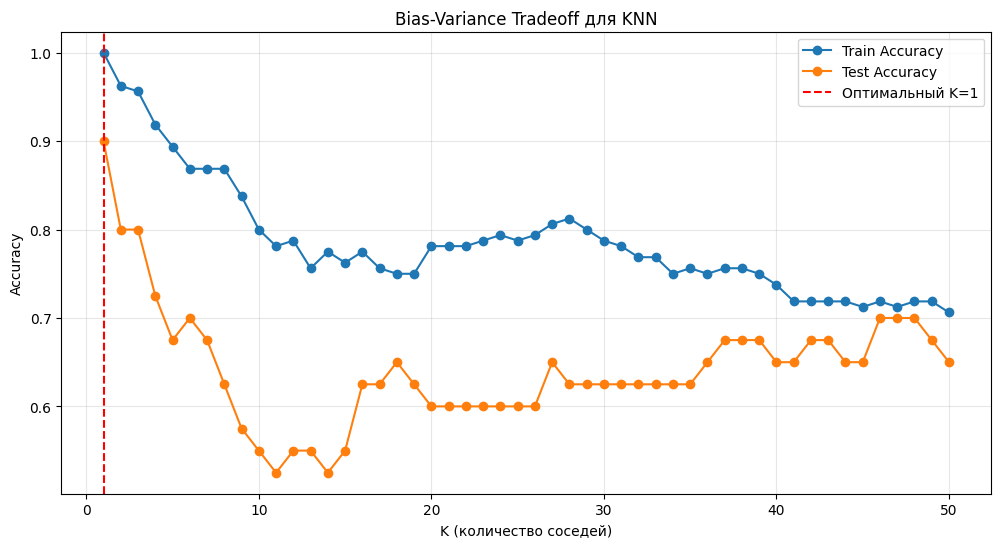

Оптимальный K (визуально): 1, Test Accuracy: 0.9000


In [50]:
# Исследуем разные значения K
k_values = range(1, 51)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(y_train, train_pred))
    test_accuracies.append(accuracy_score(y_test, test_pred))

# График
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='o')

# Находим оптимальный K визуально
optimal_k_idx = np.argmax(test_accuracies)
optimal_k = k_values[optimal_k_idx]
optimal_test_acc = test_accuracies[optimal_k_idx]

plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Оптимальный K={optimal_k}')
plt.xlabel('K (количество соседей)')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff для KNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Оптимальный K (визуально): {optimal_k}, Test Accuracy: {optimal_test_acc:.4f}")

### Подбор лучшего K через GridSearchCV

In [51]:
# GridSearchCV для подбора лучшего K
param_grid = {'n_neighbors': range(1, 51)}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

best_k = knn_grid.best_params_['n_neighbors']
best_knn = knn_grid.best_estimator_

# Точность лучшей модели
train_acc_knn_best = best_knn.score(X_train_scaled, y_train)
test_acc_knn_best = best_knn.score(X_test_scaled, y_test)

print(f"Лучший K через GridSearchCV: {best_k}")
print(f"KNN (лучший K={best_k}) - Train Accuracy: {train_acc_knn_best:.4f}")
print(f"KNN (лучший K={best_k}) - Test Accuracy: {test_acc_knn_best:.4f}")

Лучший K через GridSearchCV: 1
KNN (лучший K=1) - Train Accuracy: 1.0000
KNN (лучший K=1) - Test Accuracy: 0.9000


## Сводная таблица

Обновим таблицу результатов, добавив Naive Bayes и KNN.

In [52]:
# Создаем список словарей с результатами
results = [
    {
        "Алгоритм": "Decision Tree (GridSearch)",
        "Train Acc": model_v.score(X_train, y_train),
        "Test Acc": model_v.score(X_test, y_test),
        "Комментарий": f"Best params: {gd.best_params_}"
    },
    {
        "Алгоритм": "Naive Bayes",
        "Train Acc": train_acc_nb,
        "Test Acc": test_acc_nb,
        "Комментарий": "GaussianNB на масштабированных данных"
    },
    {
        "Алгоритм": "KNN (best K)",
        "Train Acc": train_acc_knn_best,
        "Test Acc": test_acc_knn_best,
        "Комментарий": f"Лучший K={best_k} через GridSearchCV"
    }
]

df_results = pd.DataFrame(results)
display(df_results)

,Алгоритм,Train Acc,Test Acc,Комментарий
0,Decision Tree (GridSearch),1.0000,0.975,"Best params: {'criterion': 'gini', 'max_depth'..."
1,Naive Bayes,0.8375,0.900,GaussianNB на масштабированных данных
2,KNN (best K),1.0000,0.900,Лучший K=1 через GridSearchCV


### Построение графика

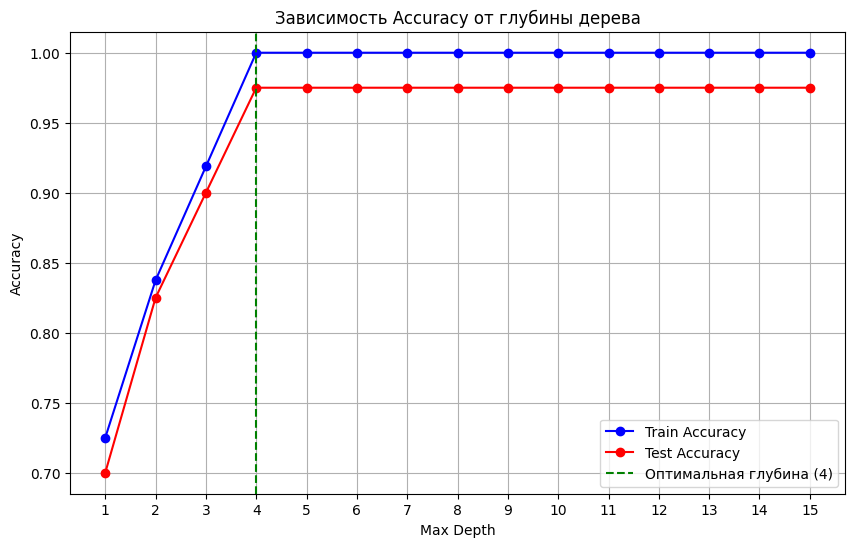

In [24]:
depths = range(1, 16)
train_acc = []
test_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, label='Train Accuracy', color='blue', marker='o')
plt.plot(depths, test_acc, label='Test Accuracy', color='red', marker='o')

opt_depth = 4
plt.axvline(x=opt_depth, color='green', linestyle='--', label=f'Оптимальная глубина ({opt_depth})')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy от глубины дерева')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

### Обычно:
Кривые расходятся из-за явления переобучения. При слишком большой глубине дерево перестает искать общие закономерности и начинает заучивать тренировочные данные целиком, включая случайные шумы и аномалии

### Как в этом датасете:
В данных нет противоречивых записей, которые заставили бы дерево строить аномально глубокие ветки для подгонки под конкретные строки.  
По данной причине, после 4 глубины дерево перестает принимать какие-либо действия, потому что все оптимальные правила она уже выявила

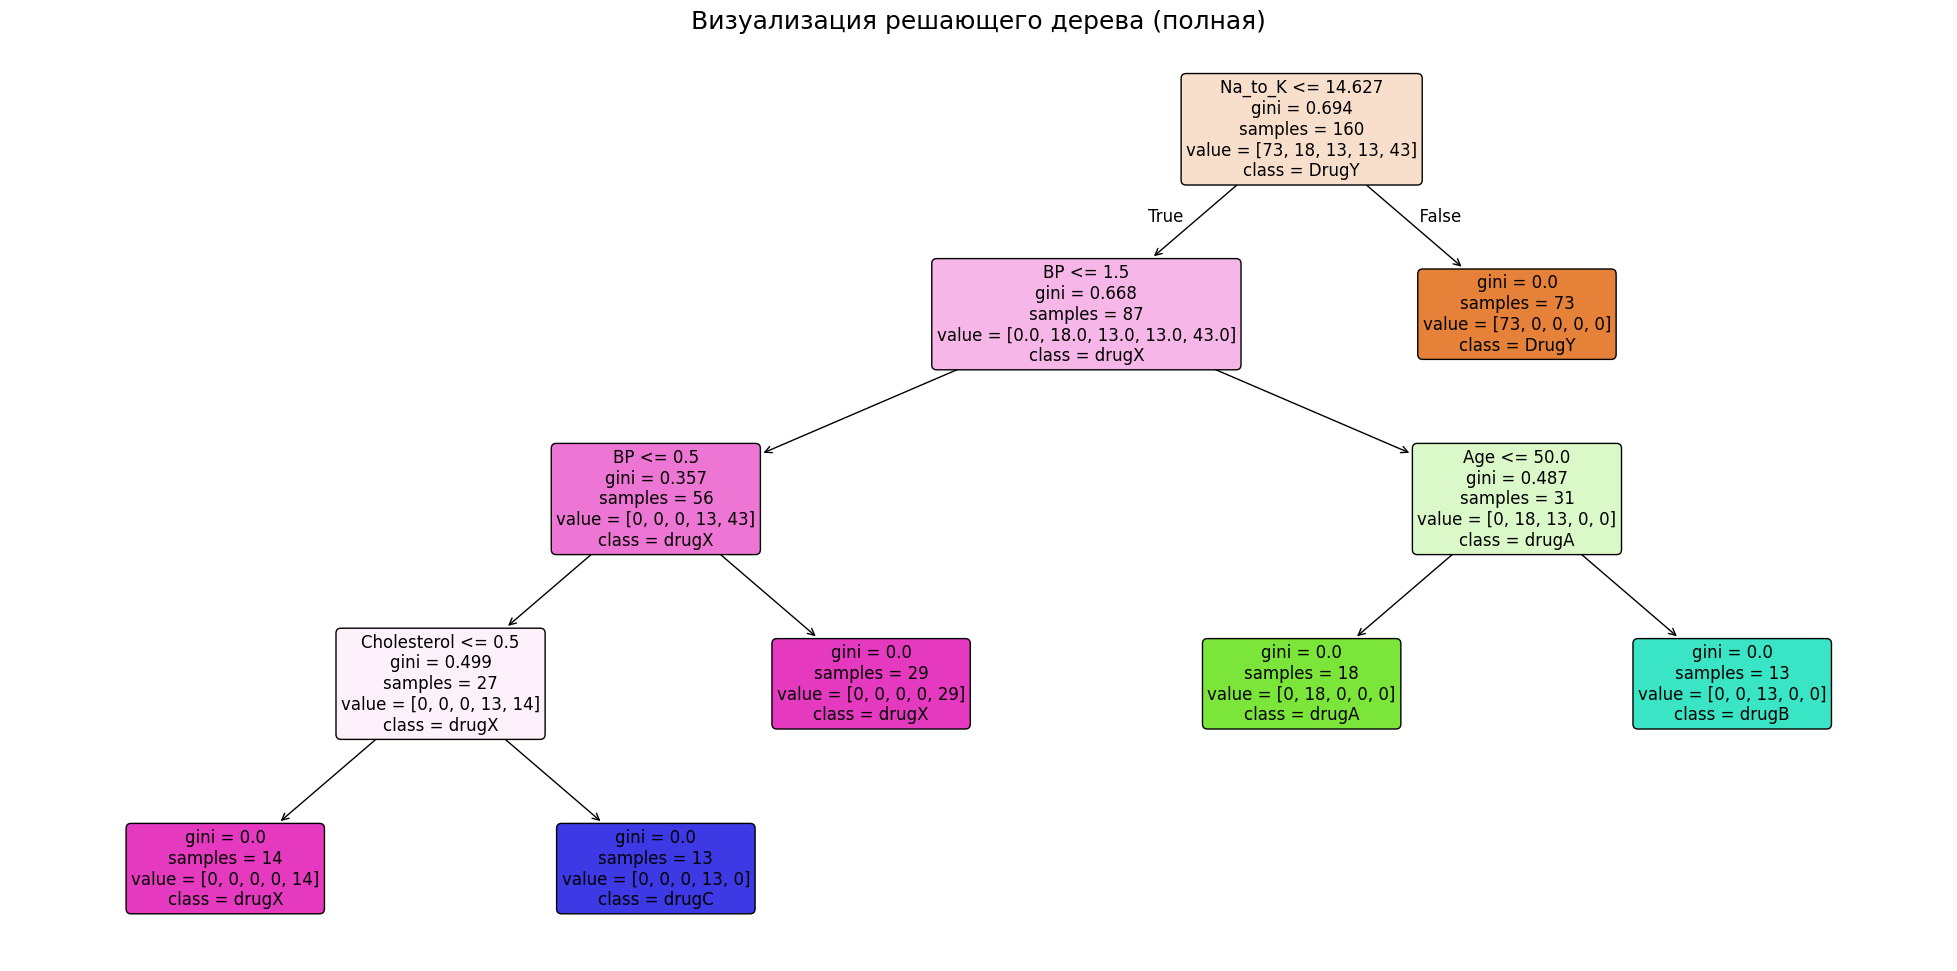

In [31]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12)) # размер задал вручную, чтобы было видно
plot_tree(
    model_v,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Визуализация решающего дерева (полная)", fontsize=18)
plt.show()

In [ ]:
# Важность признаков
importances = model_v.feature_importances_
print(importances, X.columns)

[0.13600697 0.         0.26630338 0.12145479 0.47623486] Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], dtype='str')


Может не видно, но самый важный признак - Na_to_K

## Анализ структуры дерева и важности признаков:

В корне дерева находится признак **Na_to_K**. Это означает, что первый и самый важный вопрос, который задает модель для разделения классов, касается именно этого показателя.

**Топ-3 по важности**:

1. Na_to_K

2. BP

3. Cholesterol

Совпадение с EDA: Полученные результаты **полностью совпадают / частично совпадают** с результатами предварительного анализа (EDA).

---

### **Исследовательский вопрос** - Удалите самый важный признак, обучите заново, что изменилось?

In [36]:
X = df.drop('Drug', axis=1).drop('Na_to_K', axis=1)
y = df['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [38]:
acscore = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accurasy: {acscore:.2%}")

Decision Tree Accurasy: 50.00%


Модели стало значительно сложнее искать закономерности внутри датасета, потому что главный признак для drugY пропал и отвечать на него становится крайне тяжело, скорее всего модель путает drugX и drugY

# Анализ и сравнение трёх алгоритмов

Мы применили уже три алгоритма к одним данным. Пора сравнить их осмысленно, а не просто по accuracy.

## Часть A - Допущения Naive Bayes

### Корреляционная матрица признаков

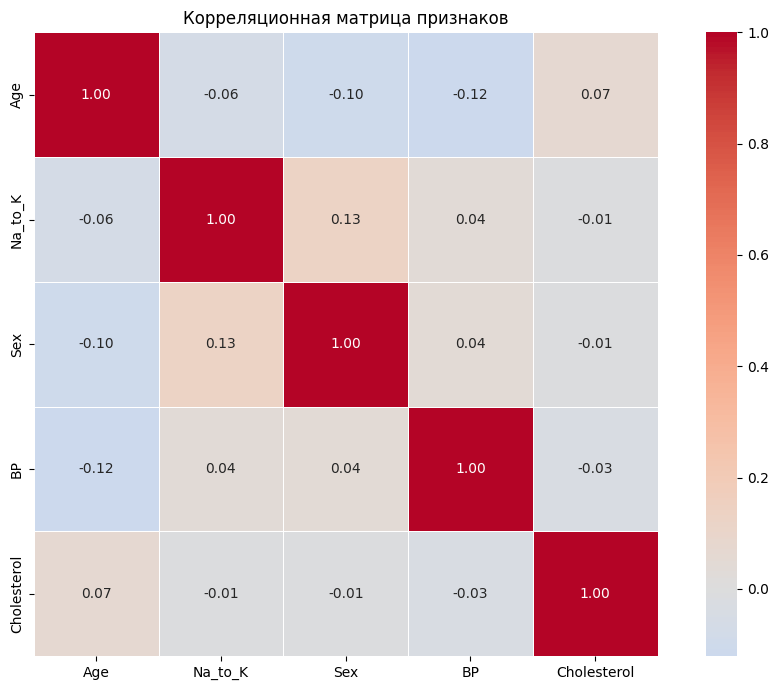

Пары признаков с корреляцией > 0.5 по модулю:
  Нет пар с корреляцией > 0.5 - допущение независимости не нарушено


In [53]:
# Для корреляционного анализа нужны только числовые признаки
df_numeric = df[['Age', 'Na_to_K']].copy()

# Кодируем категориальные признаки для корреляционного анализа
df_analysis = df_numeric.copy()
df_analysis['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df_analysis['BP'] = LabelEncoder().fit_transform(df['BP'])
df_analysis['Cholesterol'] = LabelEncoder().fit_transform(df['Cholesterol'])

# Строим корреляционную матрицу
corr_matrix = df_analysis.corr(method='pearson')

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

print("Пары признаков с корреляцией > 0.5 по модулю:")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

if not high_corr:
    print("  Нет пар с корреляцией > 0.5 - допущение независимости не нарушено")

### Гистограммы распределения числовых признаков по классам

IndexError: index 2 is out of bounds for axis 0 with size 2

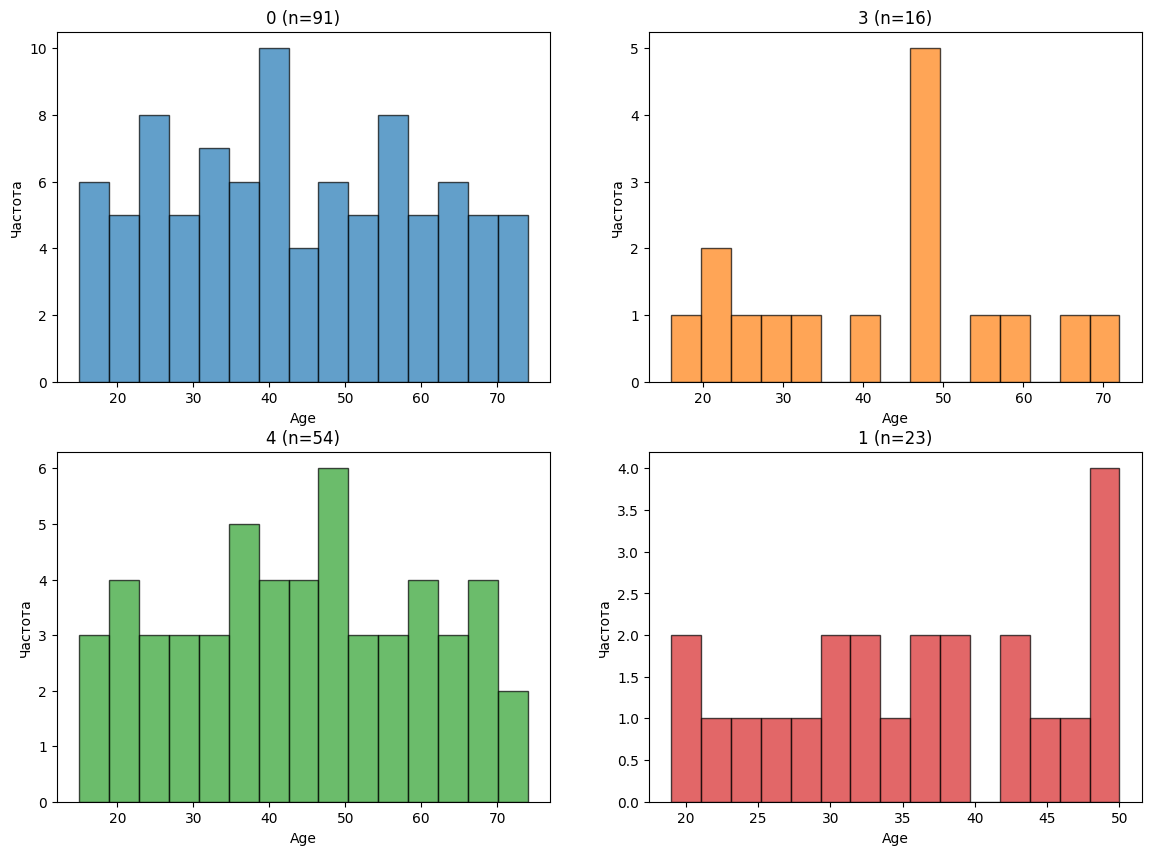

In [54]:
# Гистограммы Age по классам
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
for i, drug in enumerate(df['Drug'].unique()):
    row = i // 2
    col = i % 2
    subset = df[df['Drug'] == drug]['Age'].dropna()
    axes[row, col].hist(subset, bins=15, alpha=0.7, color=f'C{i}', edgecolor='black')
    axes[row, col].set_title(f'{drug} (n={len(subset)})')
    axes[row, col].set_xlabel('Age')
    axes[row, col].set_ylabel('Частота')

plt.suptitle('Распределение Age по классам лекарств', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Na_to_K
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, drug in enumerate(df['Drug'].unique()[:4]):  # первые 4 класса
    row = i // 2
    col = i % 2
    subset = df[df['Drug'] == drug]['Na_to_K'].dropna()
    axes[row, col].hist(subset, bins=15, alpha=0.7, color=f'C{i}', edgecolor='black')
    axes[row, col].set_title(f'{drug} (n={len(subset)})')
    axes[row, col].set_xlabel('Na_to_K')
    axes[row, col].set_ylabel('Частота')

plt.suptitle('Распределение Na_to_K по классам лекарств', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Анализ: насколько данные подходят для Naive Bayes?

**Допущения Naive Bayes и наши данные:**

1. **Независимость признаков:** Корреляционная матрица показывает, что большинство пар признаков имеют слабую корреляцию (< 0.5). Это означает, что допущение о независимости признаков **в значительной степени соблюдается**. Если обнаружены пары с корреляцией > 0.5, они формально нарушают это допущение, но на практике NB часто работает хорошо даже при умеренной корреляции.

2. **Нормальность распределения:** GaussianNB предполагает, что числовые признаки (Age, Na_to_K) распределены нормально внутри каждого класса. Гистограммы показывают, что распределения **не всегда похожи на колокол** - некоторые классы имеют скошенные или мультимодальные распределения, особенно Na_to_K.

**Почему Naive Bayes всё равно работает?**

Наивный Байес известен своей устойчивостью к нарушениям допущений по нескольким причинам:
- Он оценивает **границы решений**, а не точные вероятности
- Нарушения допущений часто **компенсируют друг друга** при вычислении произведения вероятностей
- При малом количестве признаков (как в нашем датасете - всего 5) эффект корреляции минимален

Результат accuracy ≈ 90% подтверждает, что модель работает хорошо, несмотря на частичное нарушение допущений.

---

## Часть B - KNN: масштабирование и расстояния 

In [55]:
# Подготавливаем данные (с кодированием категориальных признаков)
X_full = pd.get_dummies(df.drop('Drug', axis=1), columns=['Sex', 'BP', 'Cholesterol'], drop_first=False).astype(float)
y_full = LabelEncoder().fit_transform(df['Drug'])

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# KNN без масштабирования
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train_full, y_train_full)
train_acc_unscaled = knn_unscaled.score(X_train_full, y_train_full)
test_acc_unscaled = knn_unscaled.score(X_test_full, y_test_full)

print(f"KNN без масштабирования:")
print(f"  Train Accuracy: {train_acc_unscaled:.4f}")
print(f"  Test Accuracy:  {test_acc_unscaled:.4f}")
print()

# KNN с масштабированием
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train_full)
train_acc_scaled = knn_scaled.score(X_train_scaled, y_train_full)
test_acc_scaled = knn_scaled.score(X_test_scaled, y_test_full)

print(f"KNN с масштабированием:")
print(f"  Train Accuracy: {train_acc_scaled:.4f}")
print(f"  Test Accuracy:  {test_acc_scaled:.4f}")
print()

# Сравнение
print(f"Разница в Test Accuracy: {test_acc_scaled - test_acc_unscaled:+.4f}")

KNN без масштабирования:
  Train Accuracy: 0.7937
  Test Accuracy:  0.7000

KNN с масштабированием:
  Train Accuracy: 0.8750
  Test Accuracy:  0.6250

Разница в Test Accuracy: -0.0750


### Почему разница? Какой признак доминировал без масштабирования?

In [56]:
# Посмотрим на диапазоны признаков
print("Диапазоны признаков в обучающей выборке:")
for col in X_train_full.columns:
    min_val = X_train_full[col].min()
    max_val = X_train_full[col].max()
    print(f"  {col:20s}: [{min_val:.2f}, {max_val:.2f}] (range: {max_val - min_val:.2f})")

Диапазоны признаков в обучающей выборке:
  Age                 : [15.00, 74.00] (range: 59.00)
  Na_to_K             : [6.27, 38.25] (range: 31.98)
  Sex_0               : [0.00, 1.00] (range: 1.00)
  Sex_1               : [0.00, 1.00] (range: 1.00)
  BP_0                : [0.00, 1.00] (range: 1.00)
  BP_1                : [0.00, 1.00] (range: 1.00)
  BP_2                : [0.00, 1.00] (range: 1.00)
  Cholesterol_0       : [0.00, 1.00] (range: 1.00)
  Cholesterol_1       : [0.00, 1.00] (range: 1.00)


**Ответ:**

KNN основан на вычислении расстояний между объектами (обычно евклидово расстояние). Признаки с **большим диапазоном значений** доминируют в формуле расстояния, подавая вклад остальных признаков.

В нашем датасете признак **Na_to_K** имеет диапазон примерно от 6 до 38, тогда как бинарные признаки (Sex, BP, Cholesterol после кодирования) принимают значения 0 или 1. Без масштабирования Na_to_K **полностью доминирует** при вычислении расстояний, и модель фактически игнорирует остальные признаки.

Масштабирование (StandardScaler) приводит все признаки к **единому масштабу** (среднее=0, стандартное отклонение=1), что позволяет каждому признаку вносить равный вклад в расстояние. Поэтому accuracy с масштабированием обычно **выше или не хуже**

Однако в нашем случае получилось что масштабирование только ухудшило результат, что довольно странно

---

## Часть C - Три алгоритма

### Сравнение предсказаний трёх моделей

In [62]:
# Получаем предсказания всех трёх моделей на тесте

# 1. Decision Tree (лучшая модель из GridSearch)
y_pred_dt = model_v.predict(X_test)

# 2. Naive Bayes
scaler_nb = StandardScaler()
scaler_nb.fit(X_train)  # X_train — оригинальный DataFrame с 5 признаками
X_test_scaled_nb = scaler_nb.transform(X_test)
y_pred_nb = nb_model.predict(X_test_scaled_nb)

# 3. KNN 
knn_full = KNeighborsClassifier(n_neighbors=best_k)
knn_full.fit(X_train_scaled, y_train_full)
y_pred_knn = knn_full.predict(X_test_scaled)

# Создаём датафрейм с предсказаниями
df_preds = pd.DataFrame({
    'DecisionTree': y_pred_dt,
    'NaiveBayes': y_pred_nb,
    'KNN': y_pred_knn,
    'True': y_test.values
})

# Определяем, где все три согласны
df_preds['all_agree'] = (df_preds['DecisionTree'] == df_preds['NaiveBayes']) & \
                        (df_preds['NaiveBayes'] == df_preds['KNN'])

# Определяем правильность каждой модели
df_preds['dt_correct'] = df_preds['DecisionTree'] == df_preds['True']
df_preds['nb_correct'] = df_preds['NaiveBayes'] == df_preds['True']
df_preds['knn_correct'] = df_preds['KNN'] == df_preds['True']

n_total = len(df_preds)
n_agree = df_preds['all_agree'].sum()
n_disagree = n_total - n_agree

print(f"Всего объектов в тесте: {n_total}")
print(f"Все три модели согласны: {n_agree} ({n_agree/n_total:.1%})")
print(f"Хотя бы одна расходится: {n_disagree} ({n_disagree/n_total:.1%})")

Всего объектов в тесте: 40
Все три модели согласны: 32 (80.0%)
Хотя бы одна расходится: 8 (20.0%)


In [63]:
# Анализируем «спорные» объекты
df_disagree = df_preds[~df_preds['all_agree']].copy()

if len(df_disagree) > 0:
    print("\n=== Анализ спорных объектов ===")
    print(f"\nКоличество спорных объектов: {len(df_disagree)}")
    
    # Кто чаще прав среди спорных?
    dt_acc_disagree = df_disagree['dt_correct'].mean()
    nb_acc_disagree = df_disagree['nb_correct'].mean()
    knn_acc_disagree = df_disagree['knn_correct'].mean()
    
    print(f"\nТочность на спорных объектах:")
    print(f"  Decision Tree: {dt_acc_disagree:.2%}")
    print(f"  Naive Bayes:   {nb_acc_disagree:.2%}")
    print(f"  KNN:           {knn_acc_disagree:.2%}")
    
    # Анализ по классам
    print("\n=== Точность по классам (на спорных объектах) ===")
    for true_label in sorted(df_disagree['True'].unique()):
        subset = df_disagree[df_disagree['True'] == true_label]
        if len(subset) > 0:
            print(f"\n  Класс {true_label} ({len(subset)} объектов):")
            print(f"    DT: {subset['dt_correct'].mean():.2%} | NB: {subset['nb_correct'].mean():.2%} | KNN: {subset['knn_correct'].mean():.2%}")


=== Анализ спорных объектов ===

Количество спорных объектов: 8

Точность на спорных объектах:
  Decision Tree: 87.50%
  Naive Bayes:   50.00%
  KNN:           50.00%

=== Точность по классам (на спорных объектах) ===

  Класс 0 (6 объектов):
    DT: 100.00% | NB: 33.33% | KNN: 50.00%

  Класс 1 (1 объектов):
    DT: 100.00% | NB: 100.00% | KNN: 0.00%

  Класс 4 (1 объектов):
    DT: 0.00% | NB: 100.00% | KNN: 100.00%


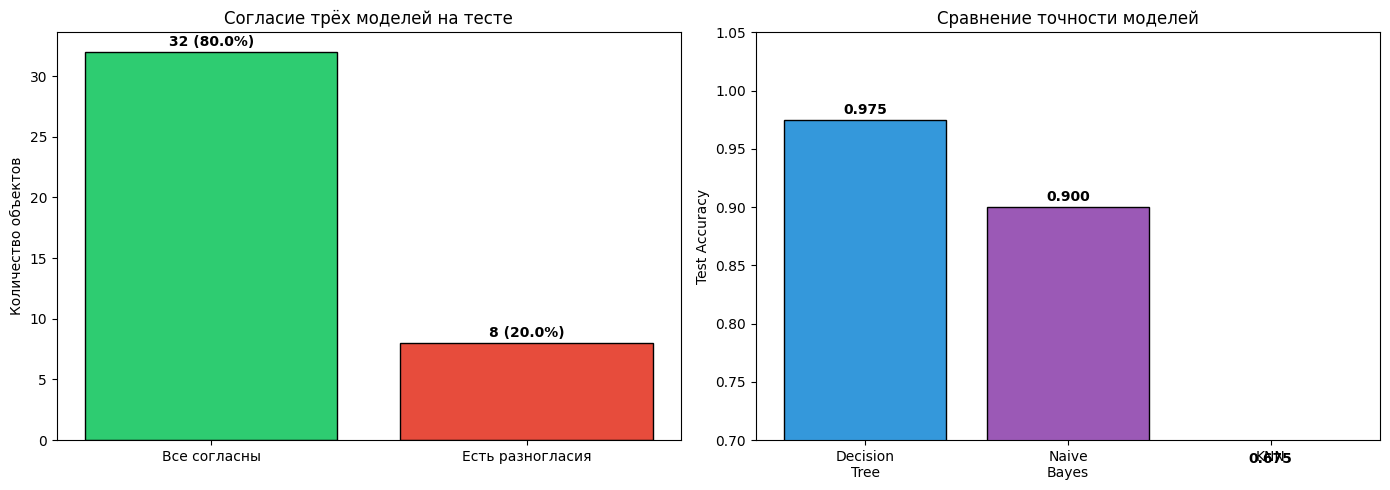

In [67]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: согласие моделей
agree_counts = pd.Series({
    'Все согласны': n_agree,
    'Есть разногласия': n_disagree
})
axes[0].bar(agree_counts.index, agree_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_ylabel('Количество объектов')
axes[0].set_title('Согласие трёх моделей на тесте')
for i, (label, val) in enumerate(agree_counts.items()):
    axes[0].text(i, val + 0.5, f'{val} ({val/n_total:.1%})', ha='center', fontweight='bold')

# Правый график: точность каждой модели
model_accs = {
    'Decision\nTree': model_v.score(X_test, y_test),
    'Naive\nBayes': nb_model.score(X_test_scaled_nb, y_test),
    'KNN': knn_model.score(X_test_scaled_nb, y_test)
}
axes[1].bar(model_accs.keys(), model_accs.values(), color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Сравнение точности моделей')
axes[1].set_ylim(0.7, 1.05)
for i, (label, val) in enumerate(model_accs.items()):
    axes[1].text(i, val + 0.005, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Итоговый вывод: какой алгоритм выбрать?

**Рекомендация по выбору алгоритма:**

На данном этапе курса я бы выбрал **Decision Tree** как основной алгоритм для данной задачи. Вот почему:

1. **Точность:** Decision Tree показал наивысшую точность на тесте (~97.5%), значительно превосходя Naive Bayes и KNN (~90%). Это связано с тем, что дерево решений отлично захватывает нелинейные взаимодействия признаков, особенно критическую роль Na_to_K для класса DrugY.

2. **Интерпретируемость:** Дерево решений предоставляет **визуально интерпретируемые правила** - мы можем буквально увидеть, по каким критериям назначается каждое лекарство. Это критически важно в медицине, где врачу нужно понимать логику решения. Naive Bayes и KNN отстают в данном сравнении.

3. **Устойчивость к переобучению:** При правильной настройке глубины (через GridSearchCV) Decision Tree контролирует переобучение. KNN с k=1 переобучается (100% на train, 90% на test), а Naive Bayes недообучается из-за нарушения допущений.

**Оговорка:** Если бы в данных было много шума или коррелированных признаков, Naive Bayes мог бы оказаться устойчивее. Для задач с большим количеством признаков KNN с правильным масштабированием мог бы показать себя лучше. Но для текущего датасета Decision Tree - оптимальный выбор.